# Dataset Analysis for Numericals Datasets

## Libraries


In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
%store -r data
data=data

%store -r numerical_cols
numerical_cols=numerical_cols



##  Descriptive Analysis

#### Numerical Data

In [3]:
numerical_cols= data.select_dtypes(include=['int64','float64' ]).columns.tolist()
print(data[numerical_cols].columns)
print(data[numerical_cols])

Index(['year of manufacture', 'Engine power (kilowatt)',
       'Engine power (Horsepower)', 'Cubic capacity', ' Number of gears',
       'CO2 (g/km)', 'Tank capacity', 'Mileage', 'Empty weight (kg)',
       'Permitted gross weight', 'Acceleration (0-100Km/h)', 'max_speed_kmh',
       'Nber of gears', 'Nber of seats', 'Nber previous owners',
       'Number of doors', 'damaged_front', 'damaged_rear', 'damaged_link_side',
       'damaged_right_side', 'damaged_interior', 'damaged_exterior',
       'accessory_missing', 'damaged_tire', 'damaged_rim', 'damaged_roof_beam',
       'damaged_mirror', 'damaged_link_door', 'damaged_right_door',
       'Nber_of_key', 'missing_winter_tires', 'major_inspection_due',
       'comfort_features', 'navigation_sytem', 'safety_features',
       'leasing_car', 'damaged_repair', 'has_winter_package',
       'has_seat_heating_front', 'has_metallic_paint',
       'space_saver_spare_wheel', 'has_headlight_washer',
       'has_foldable_front_passenger_seat', 'has

In [4]:
def kde_plot(x):
    col = x[0]

    plt.figure(figsize=(12,6))

    # Histogramm
    sns.histplot(data[x[0]], kde=False, alpha=0.25)

    # KDE-Plot
    sns.kdeplot(data[x[0]], linewidth=5)
    
    # Calculate mean and median
    mean=data[col].mean()
    median=data[col].median()
    
    # Add mean and median lines
    plt.axvline(mean, color='r', linestyle='--', label=f'Mean: {mean:.2f}')
    plt.axvline(median, color='g', linestyle='-', label=f'Median: {median:.2f}')
    
    # Add legend and labels
    plt.legend()
    plt.title(f'KDE Plot of {col}')
    plt.xlabel(x)
    plt.ylabel('Density')

    return plt.show()



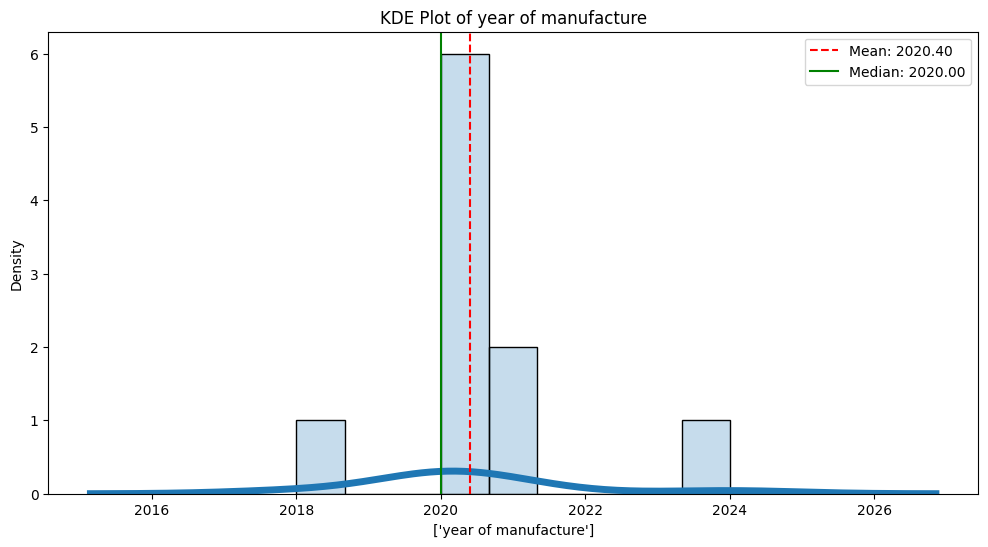

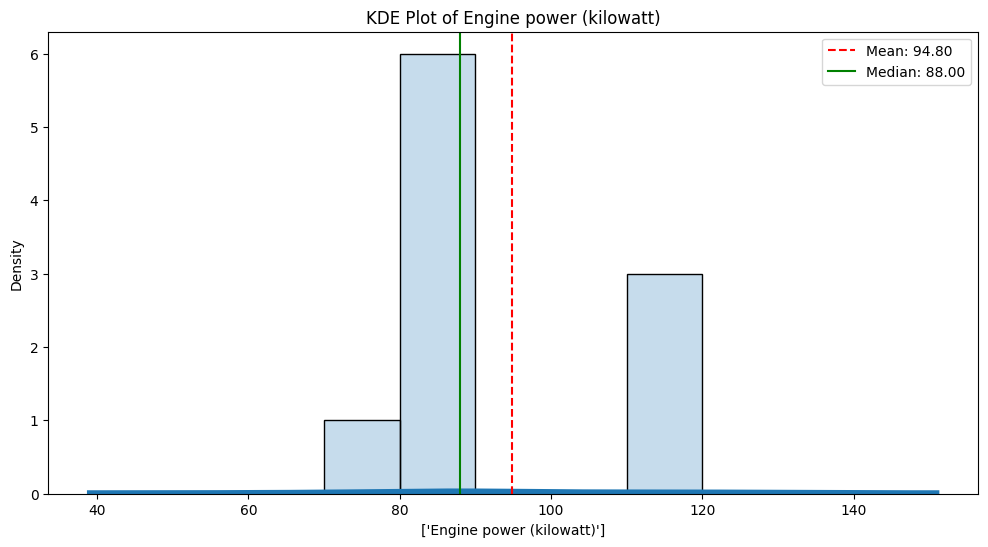

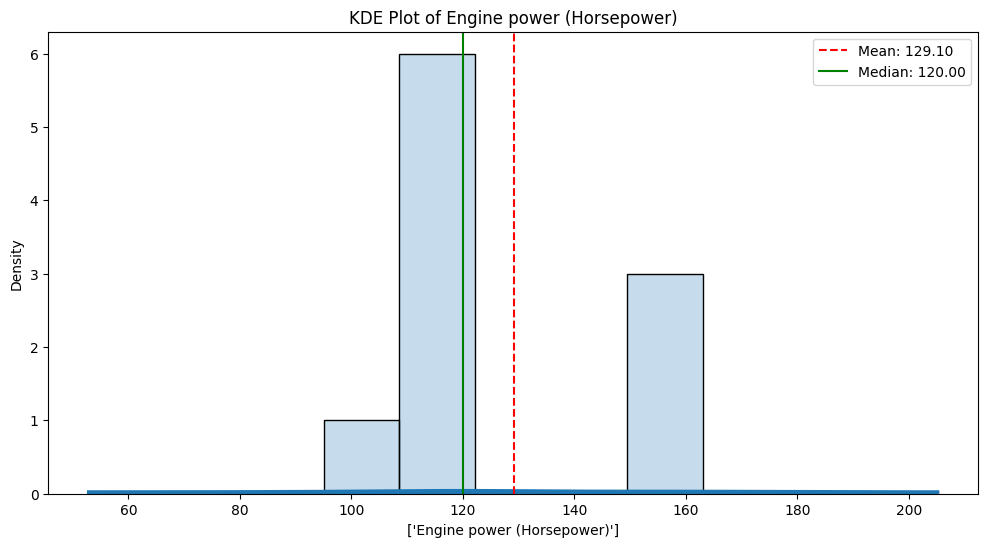

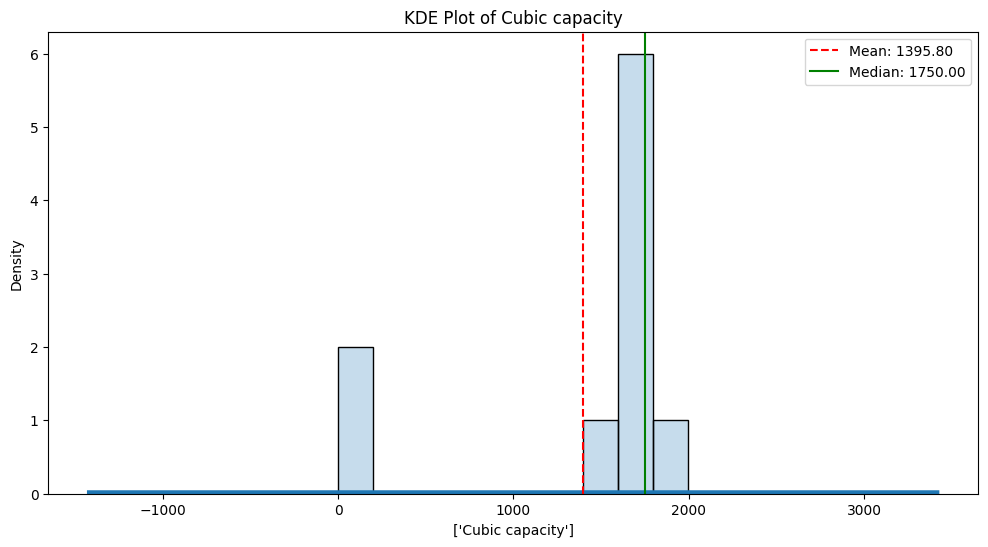

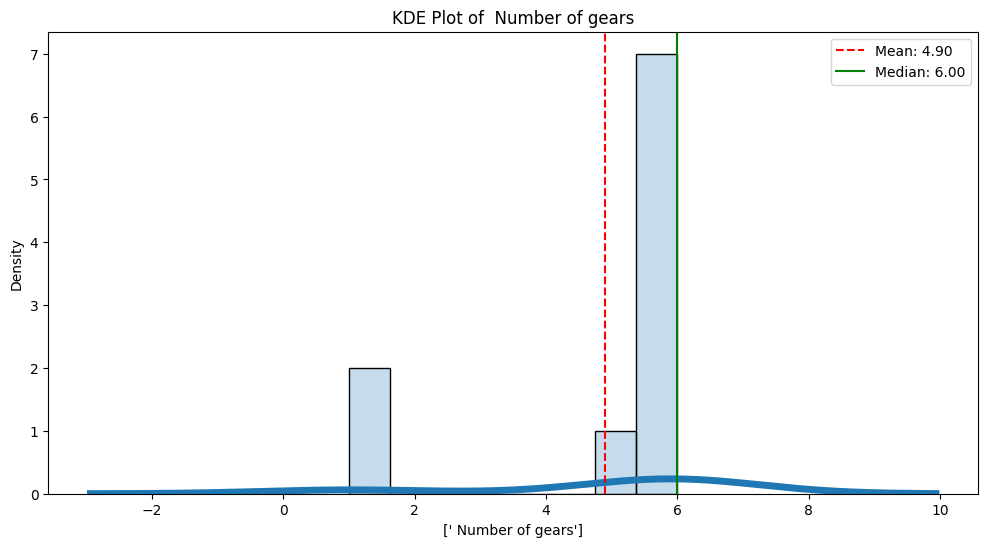

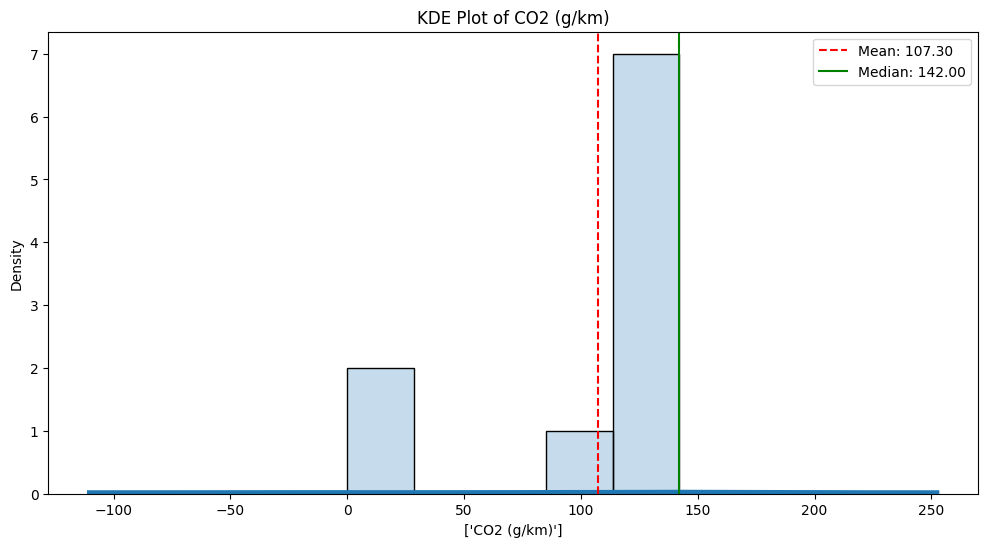

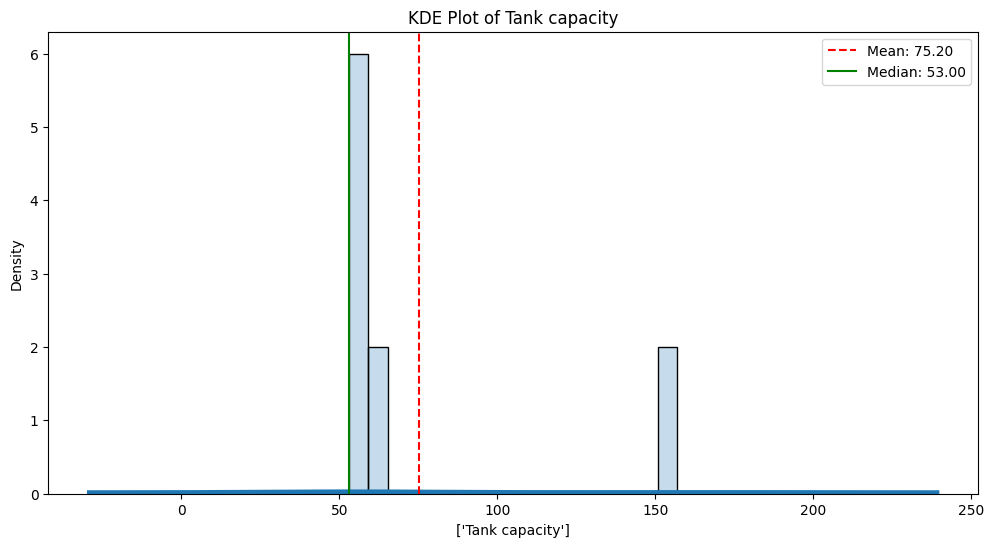

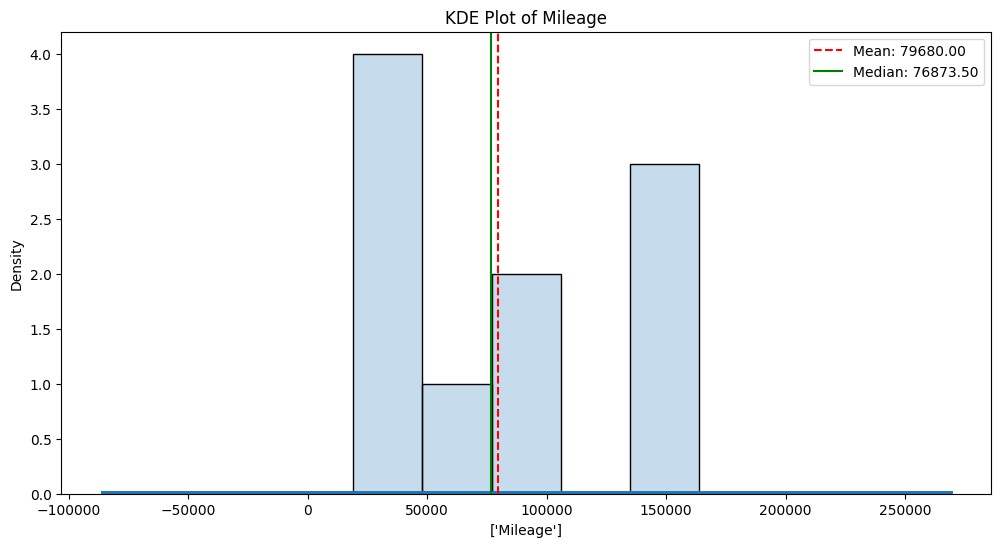

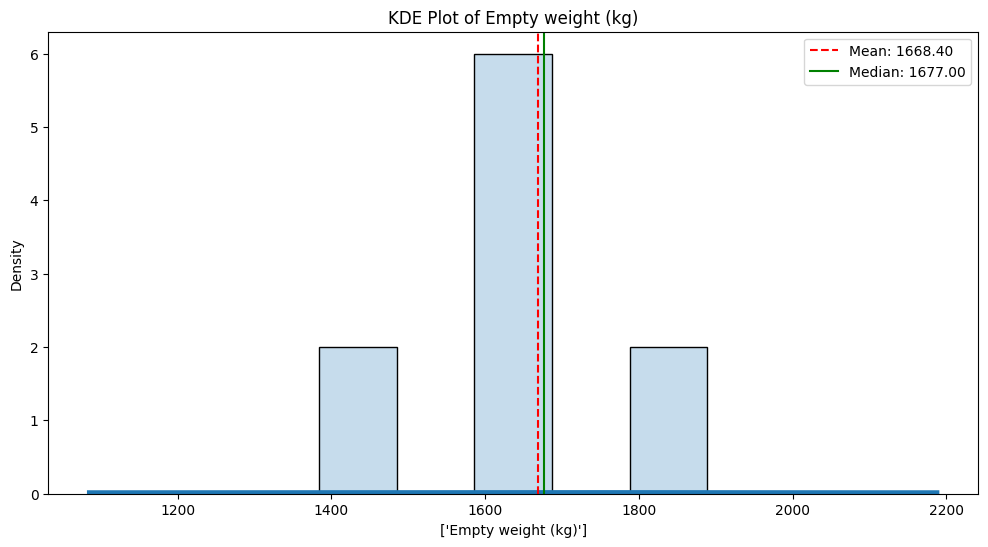

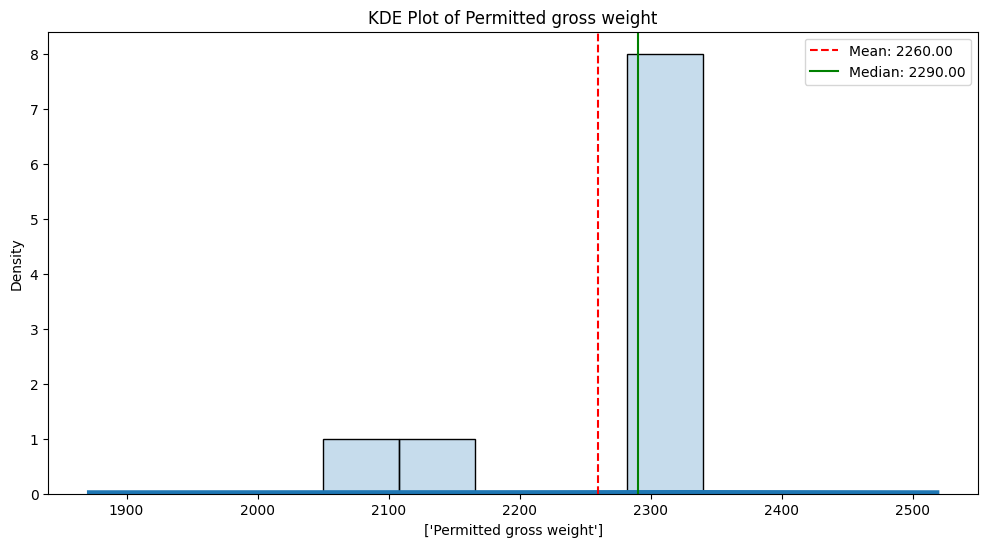

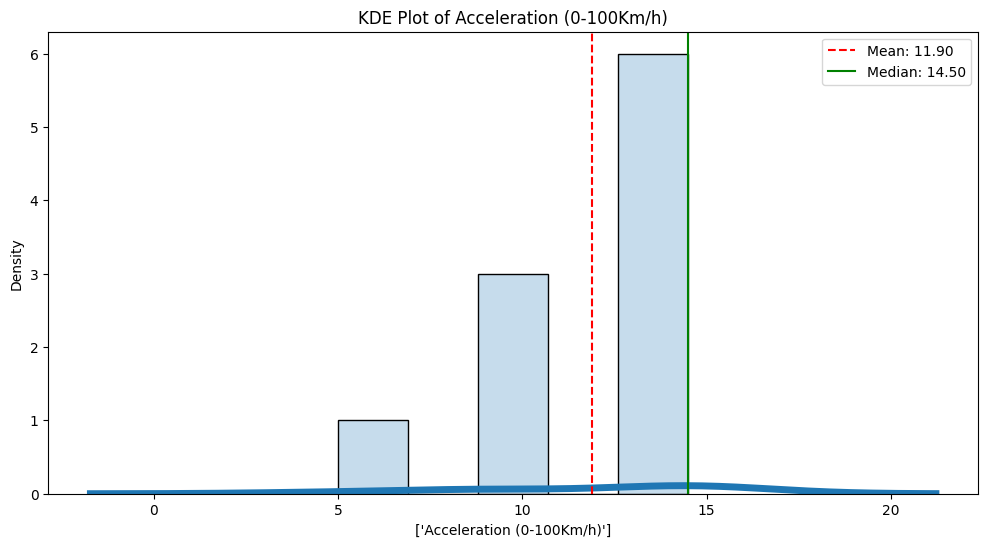

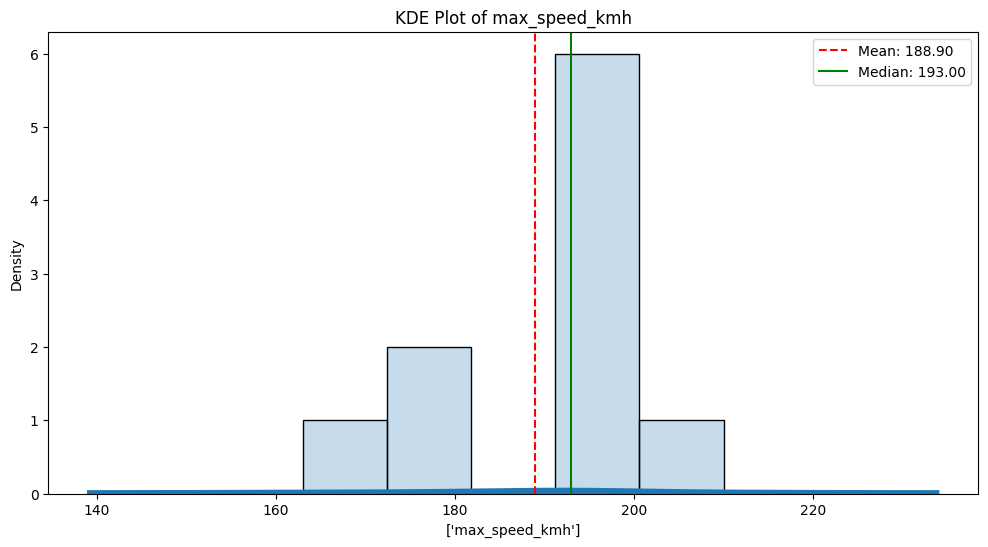

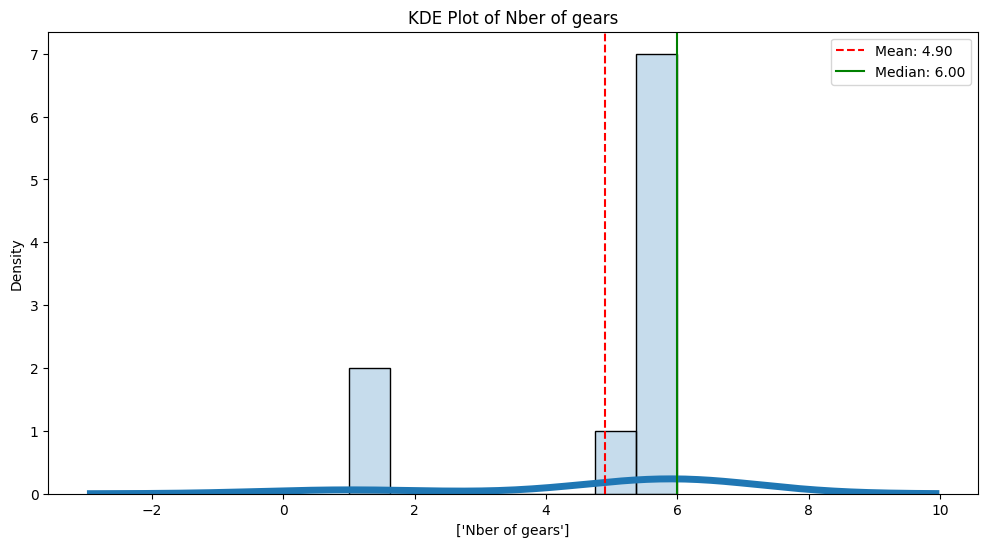

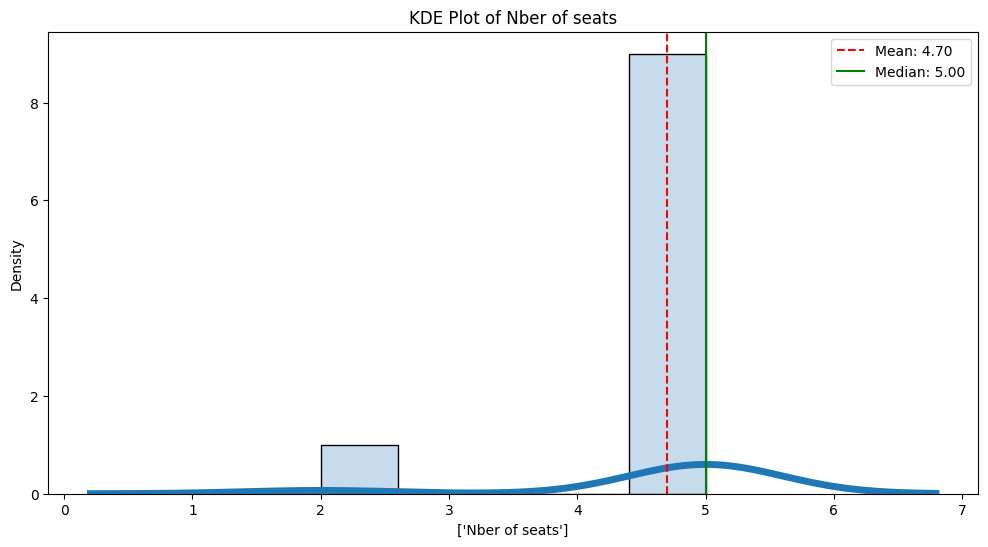

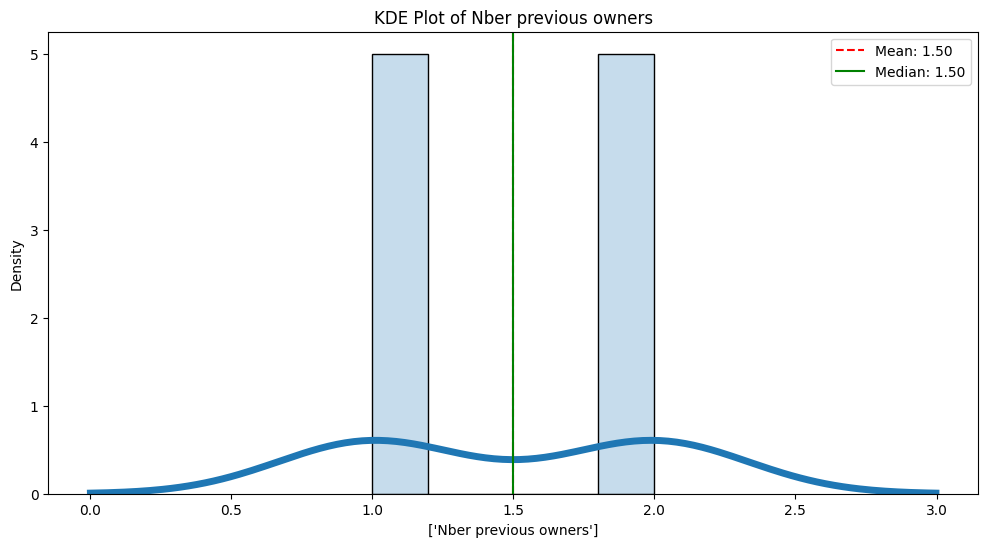

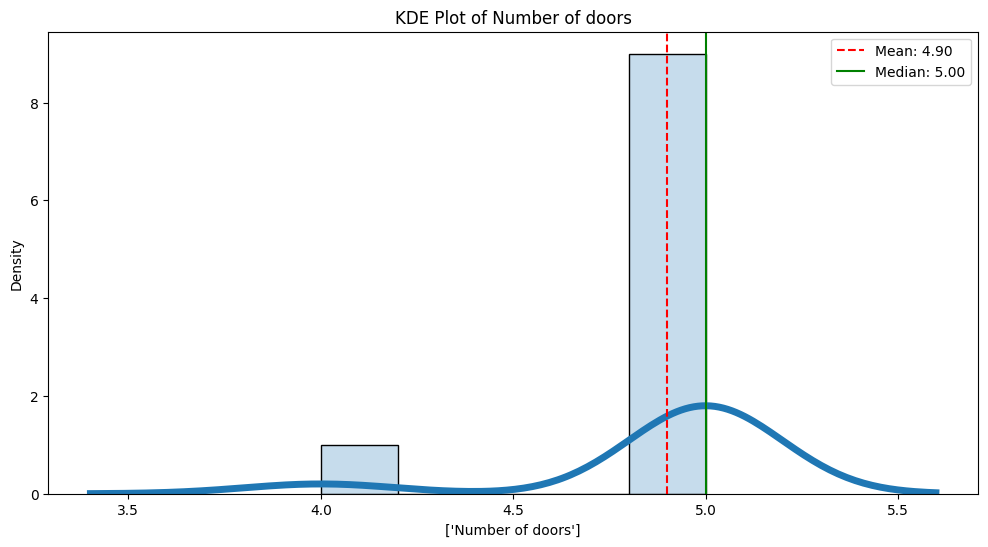

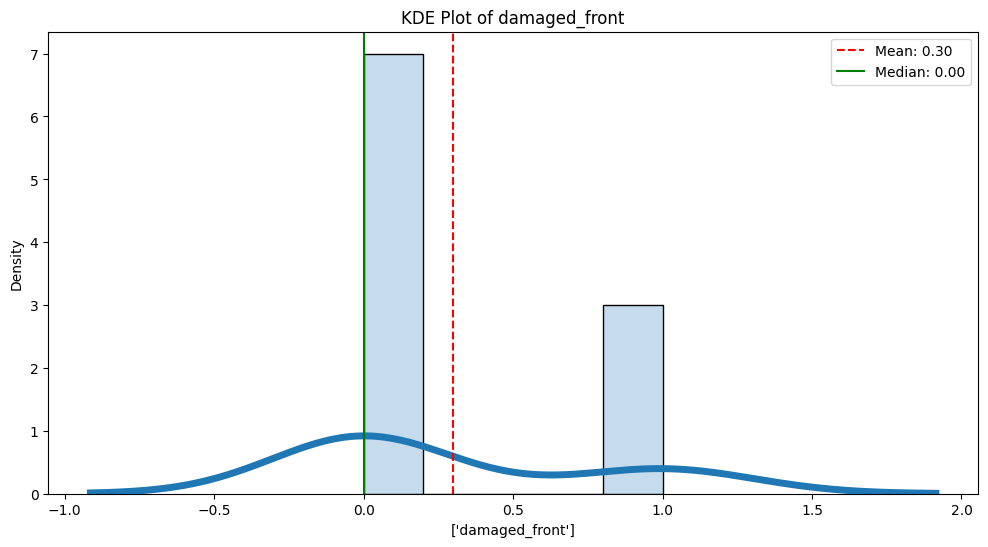

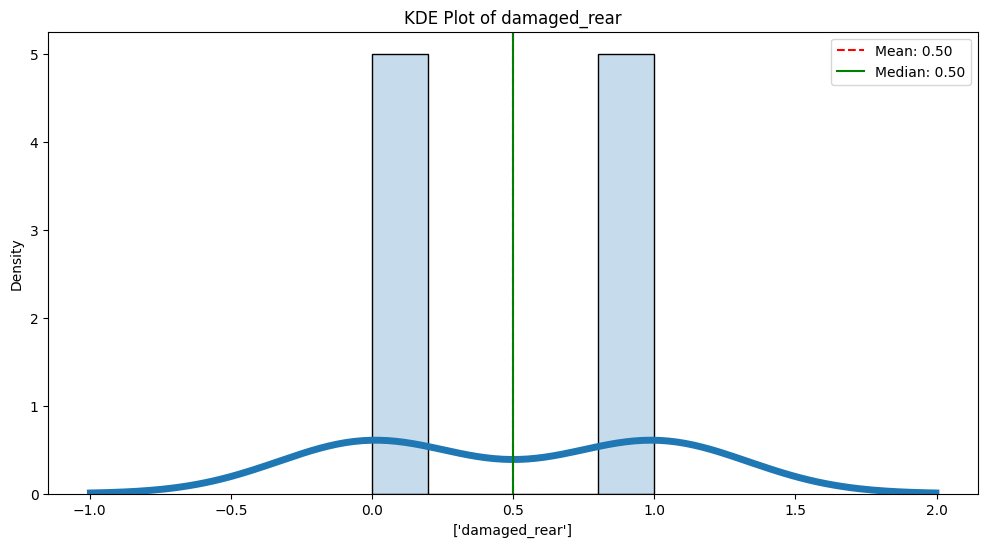

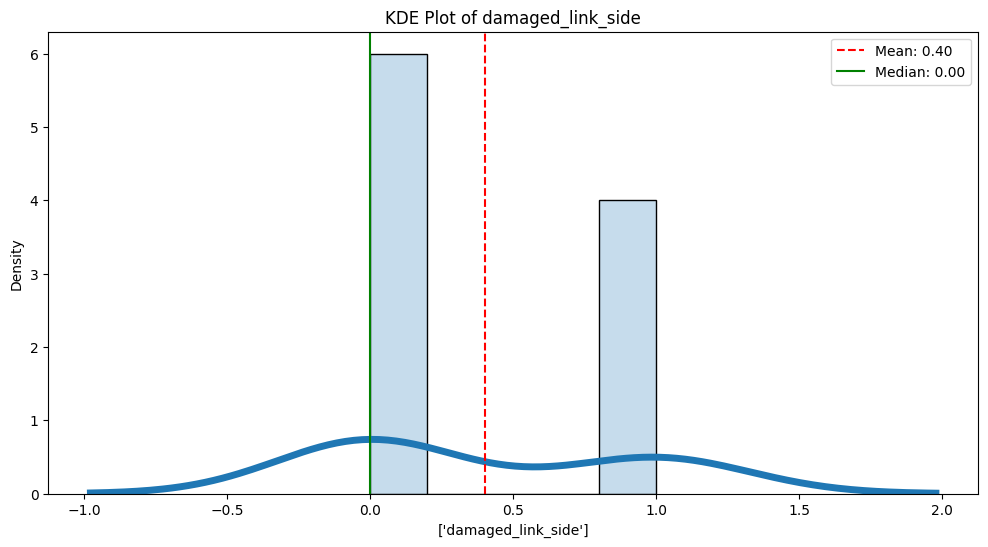

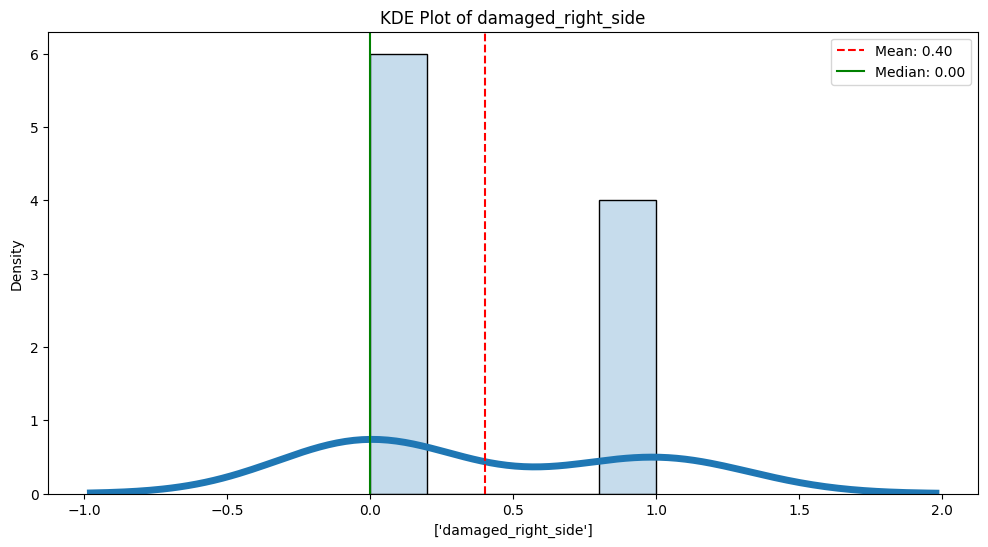

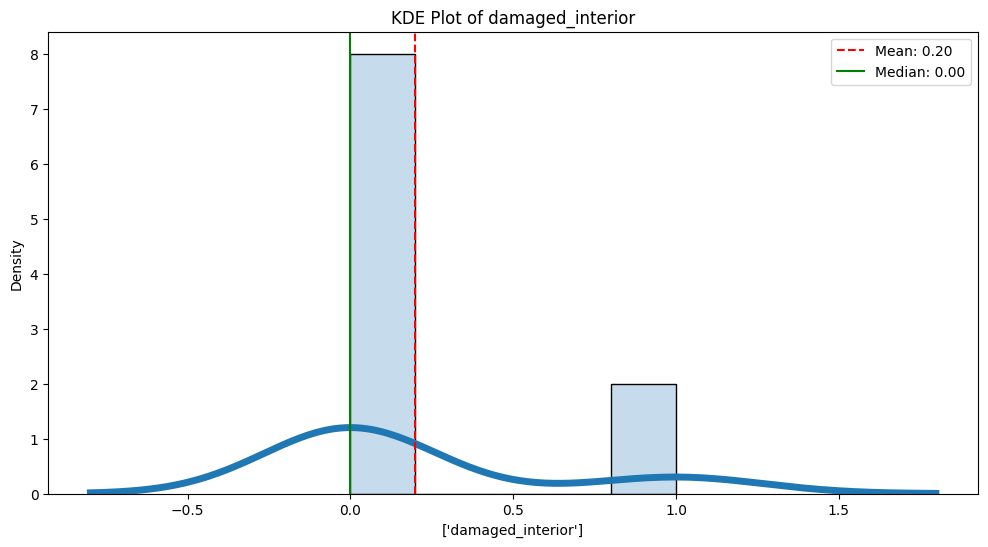

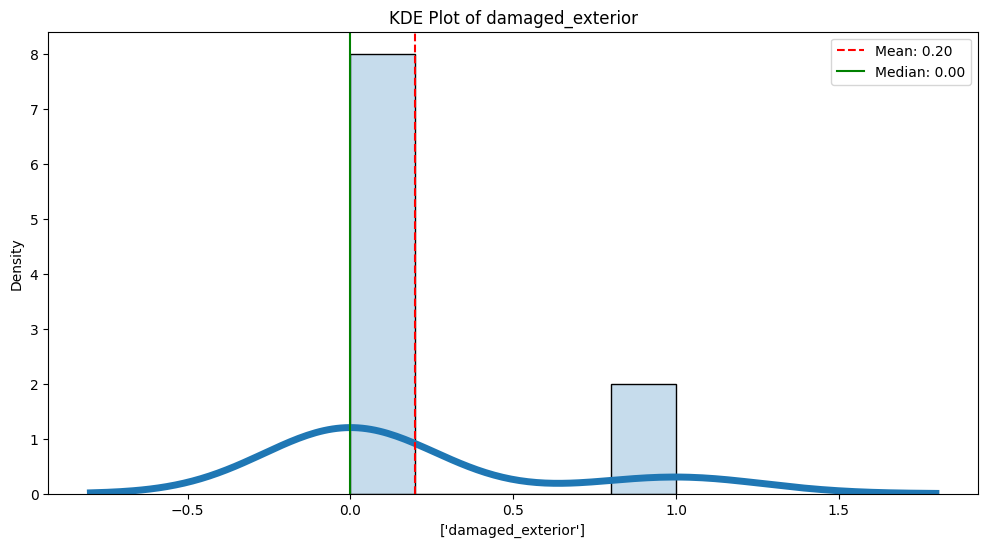

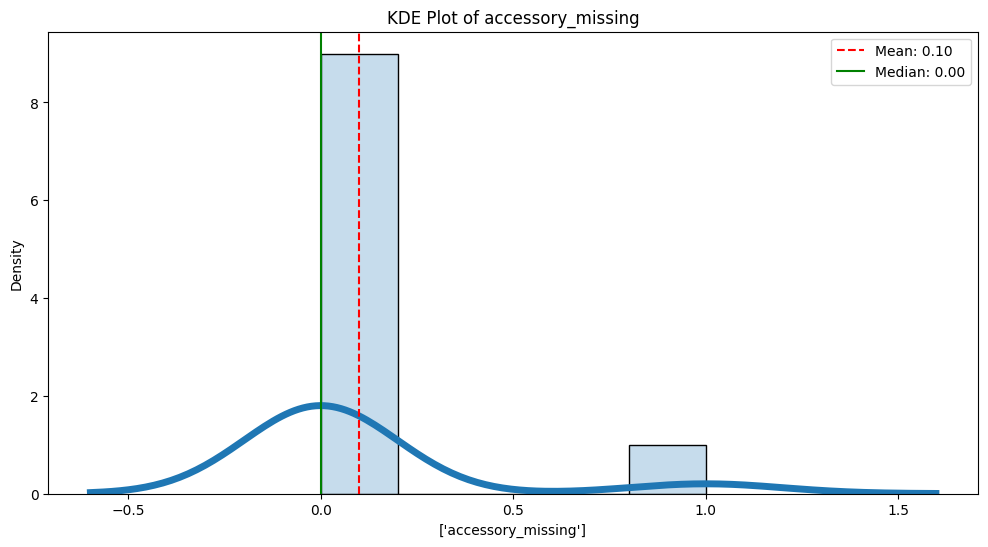

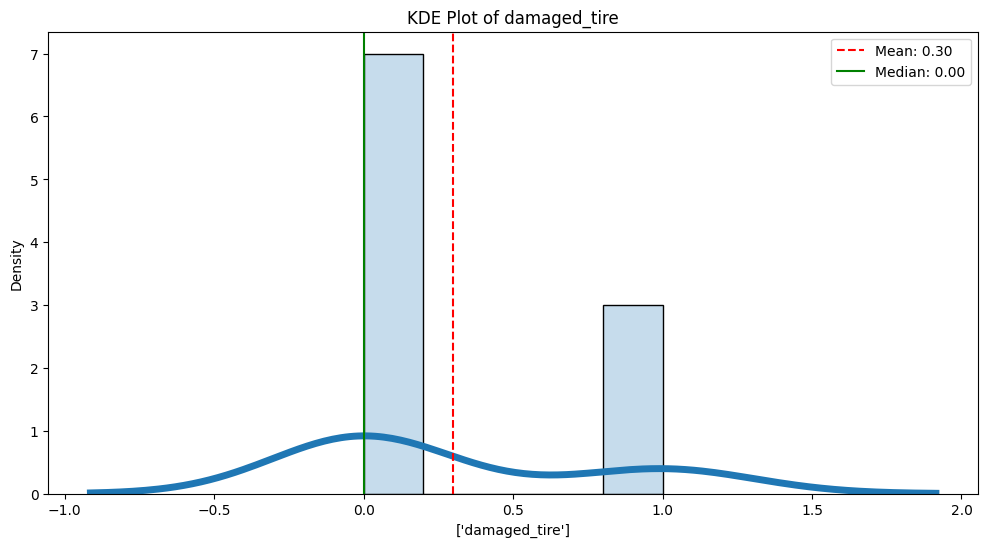

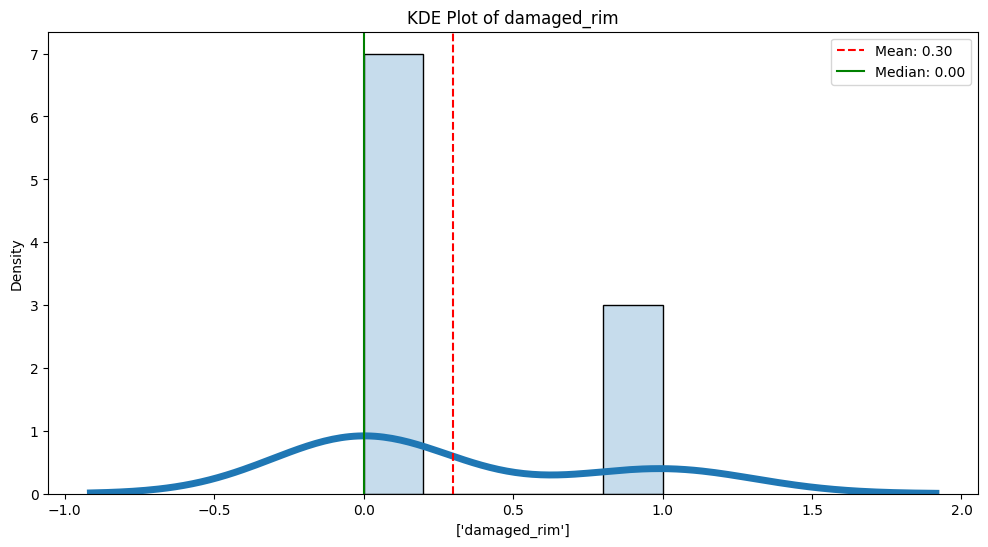

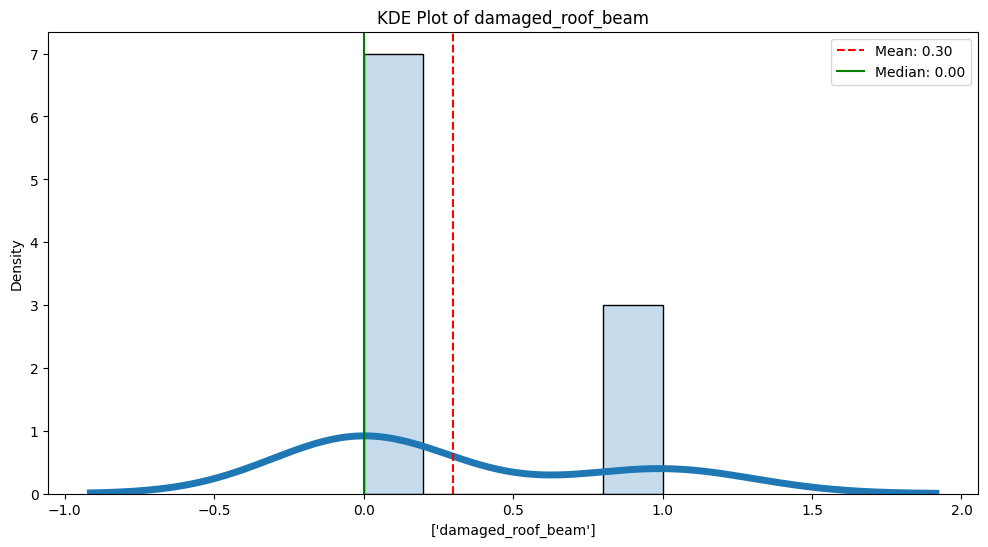

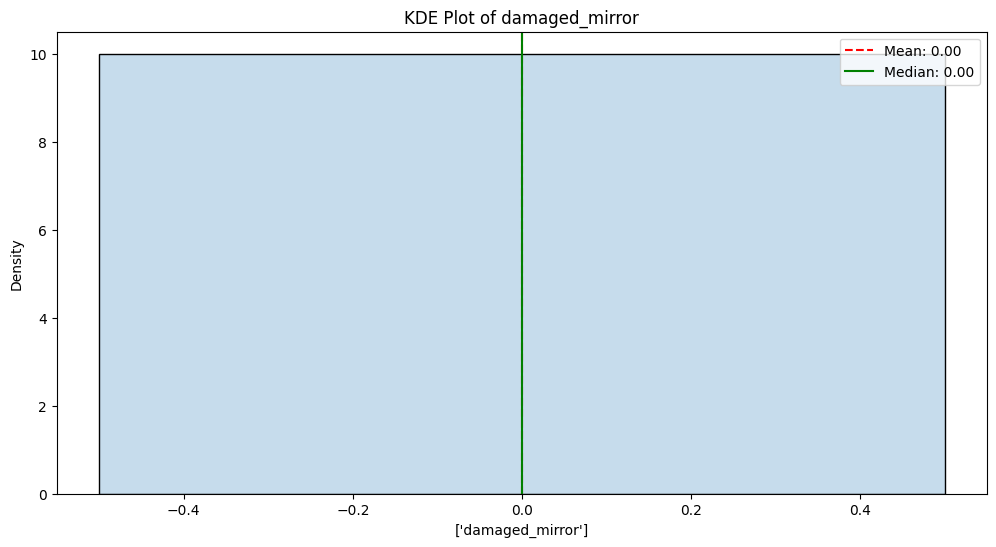

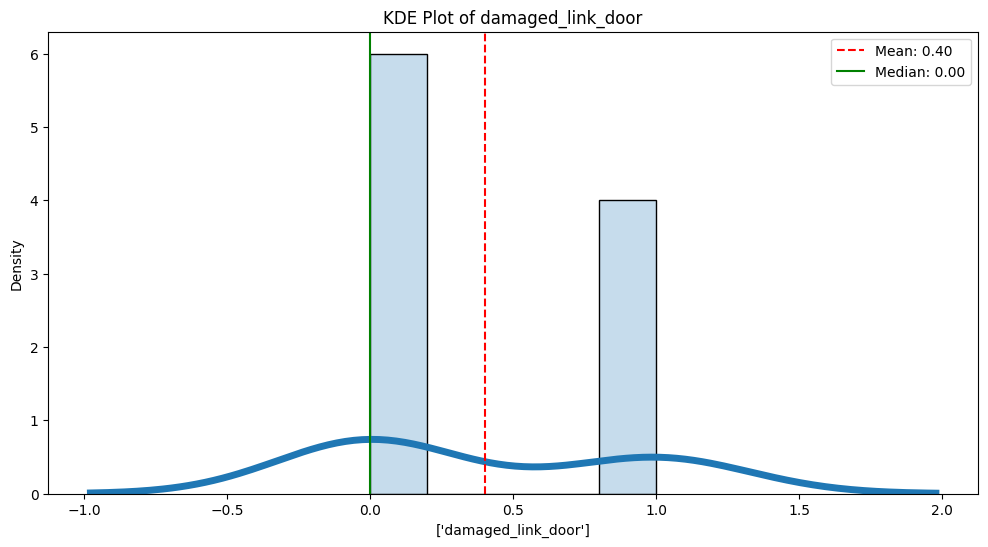

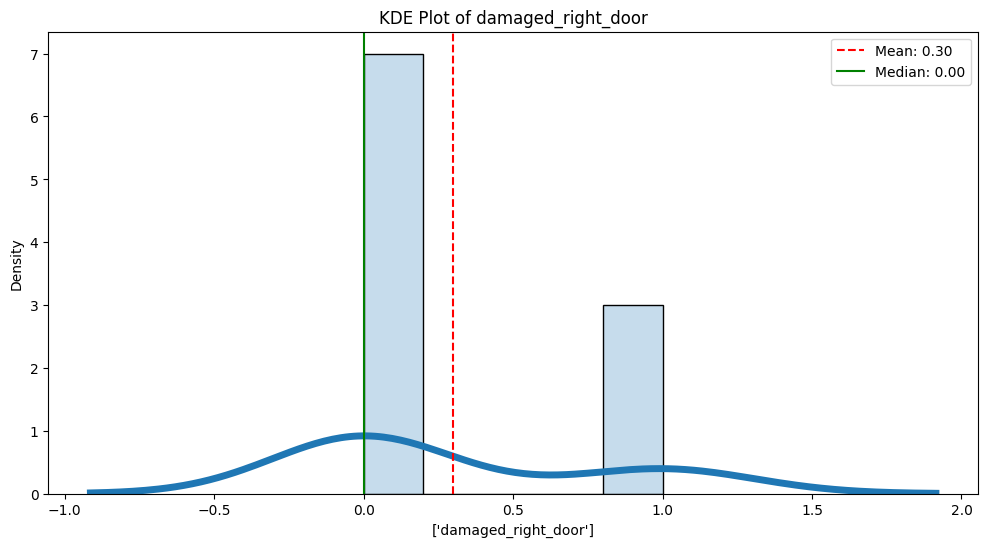

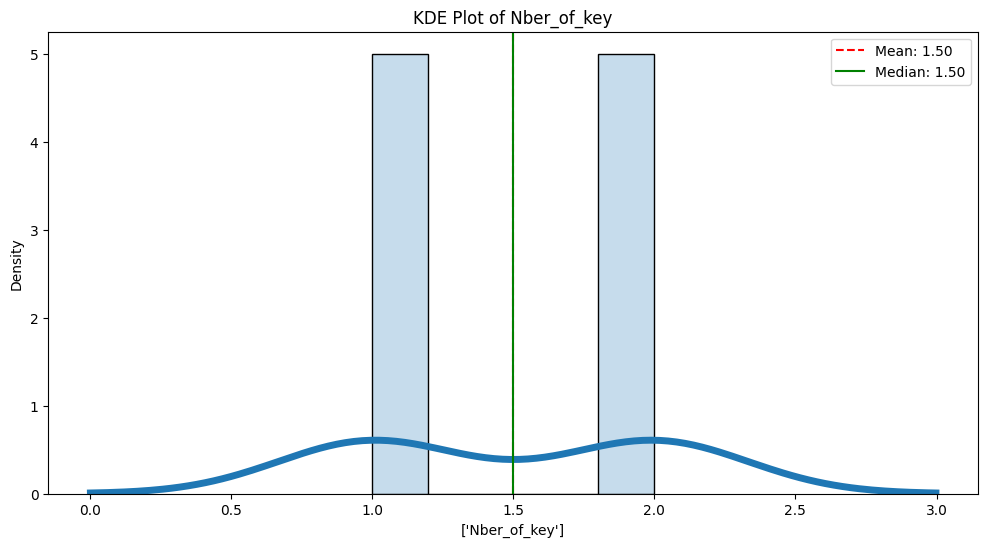

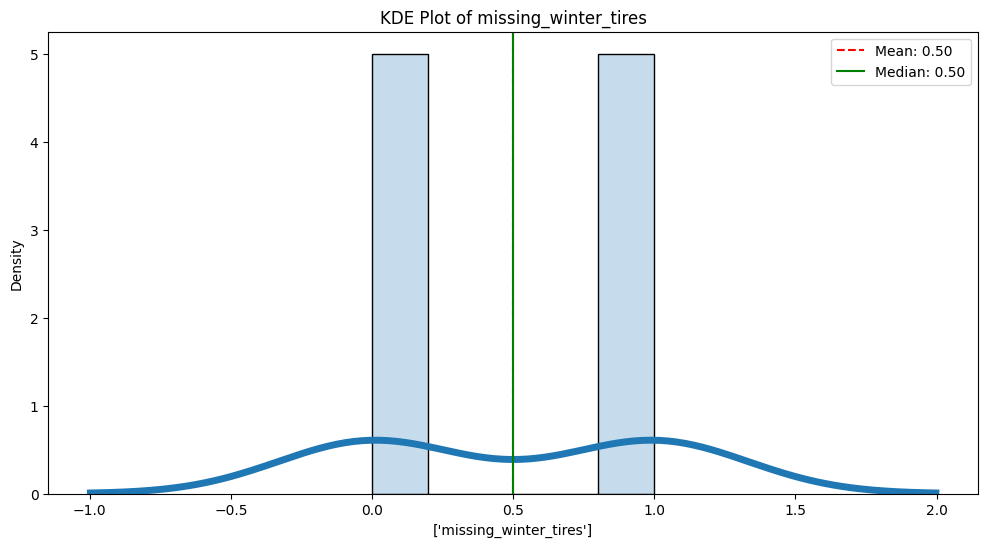

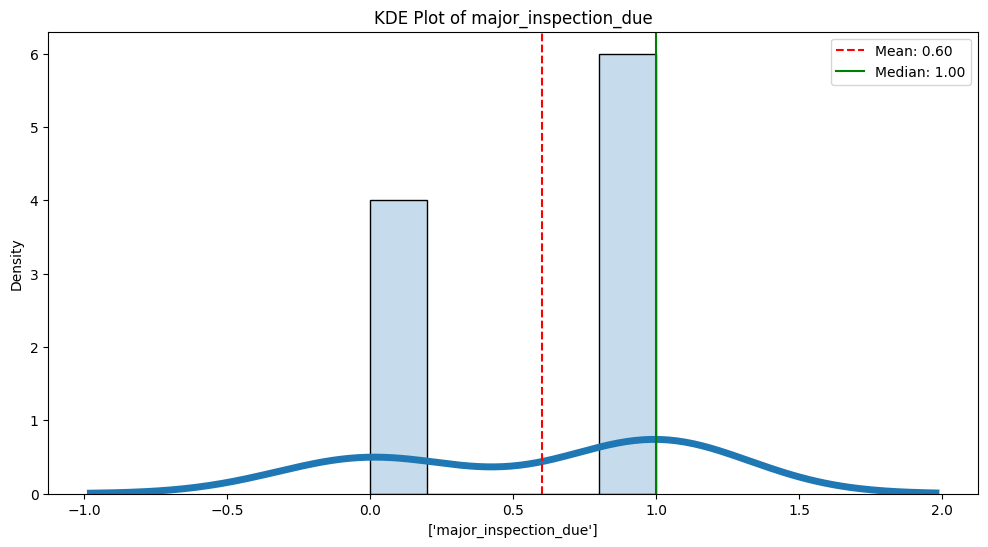

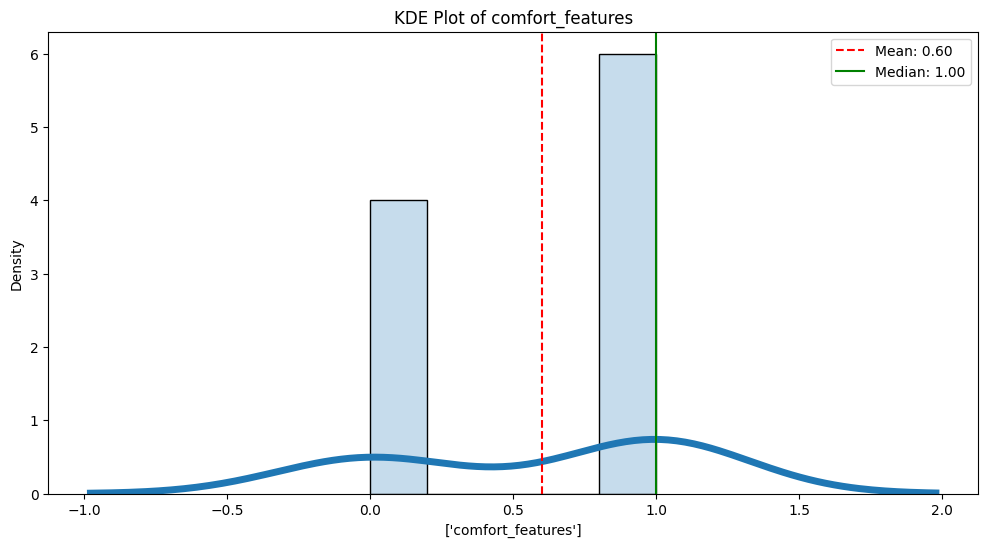

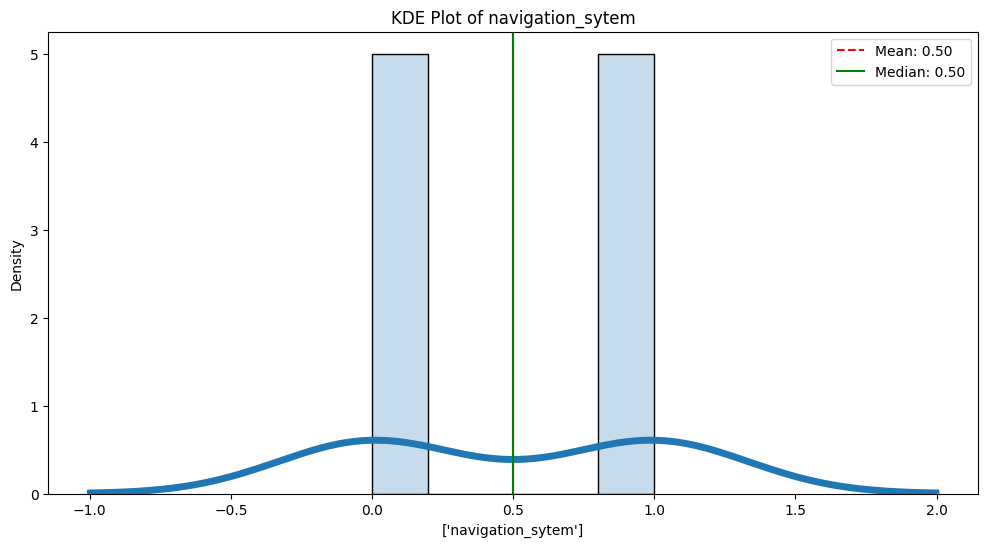

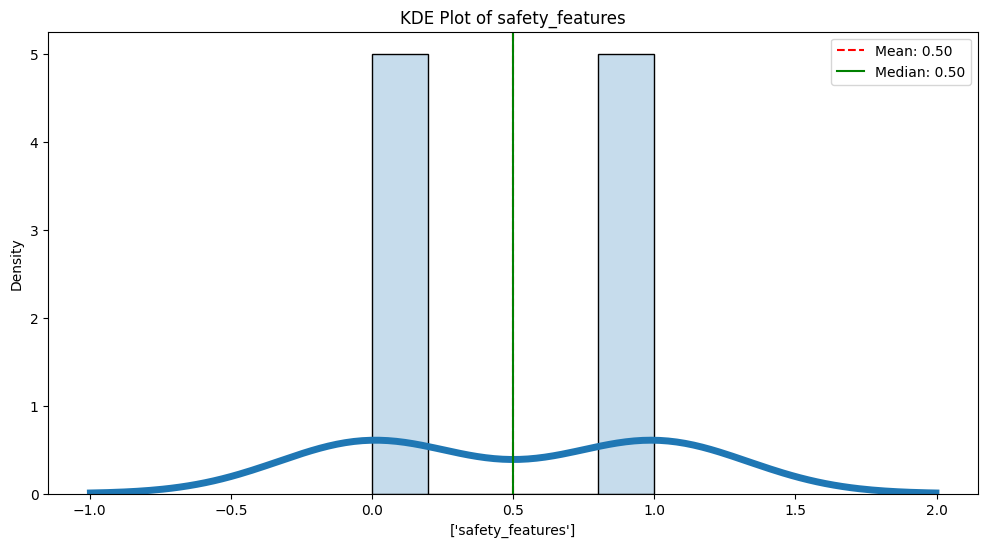

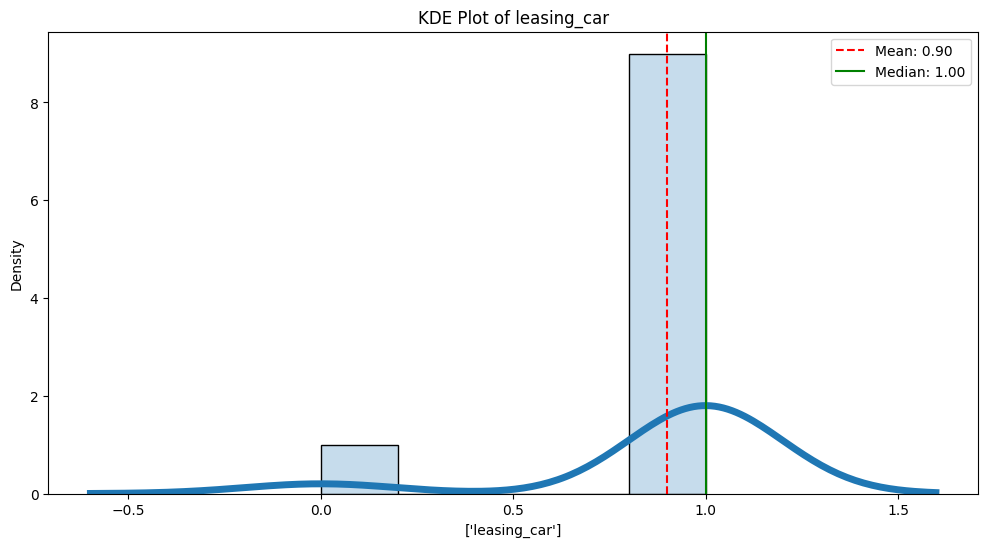

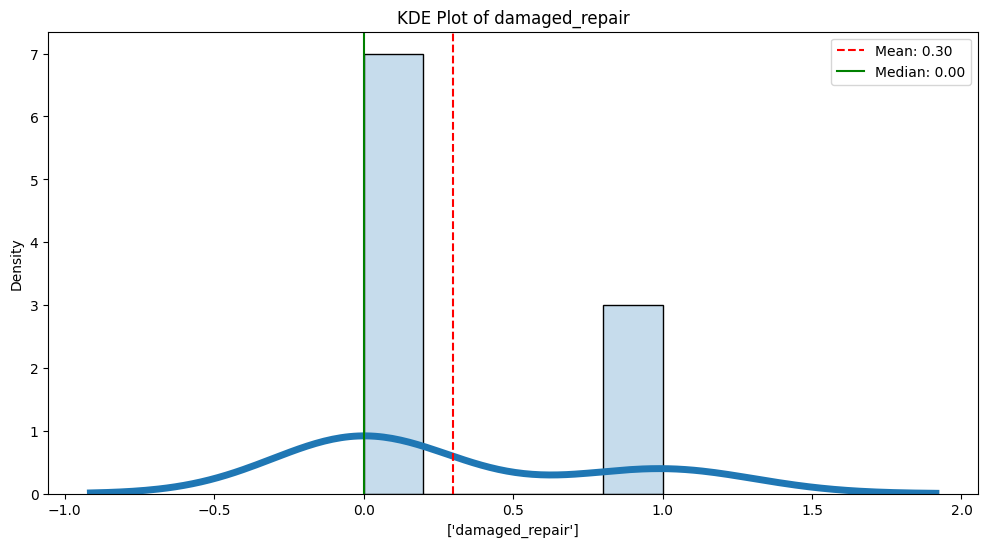

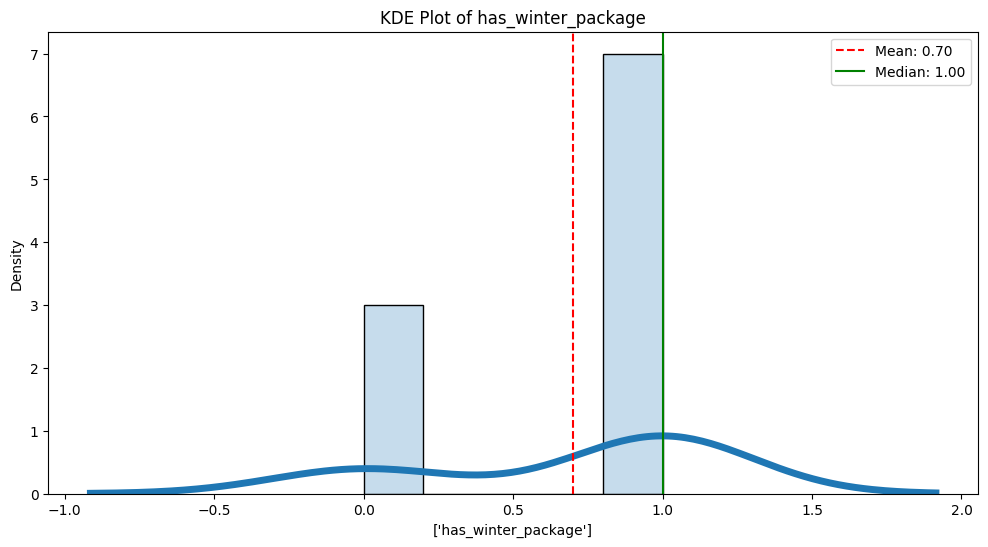

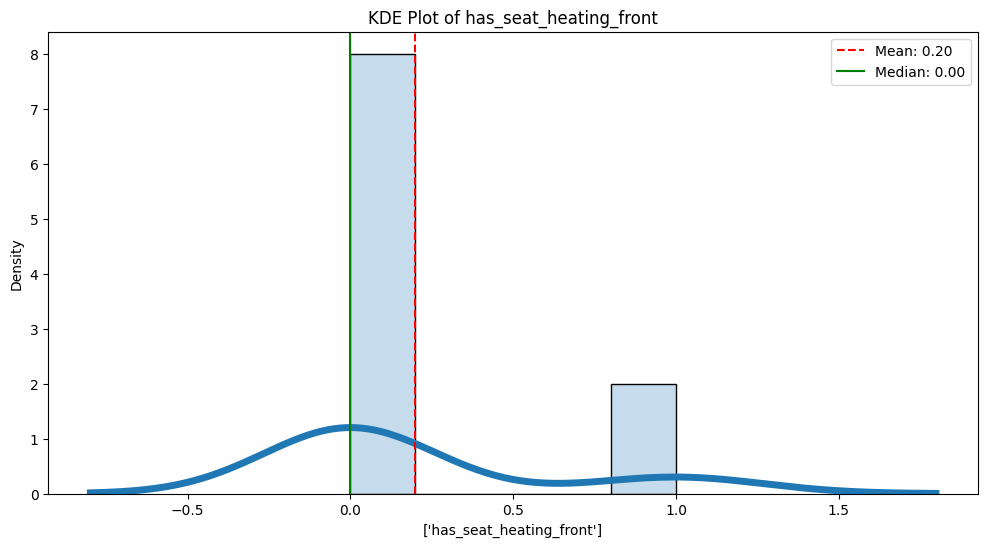

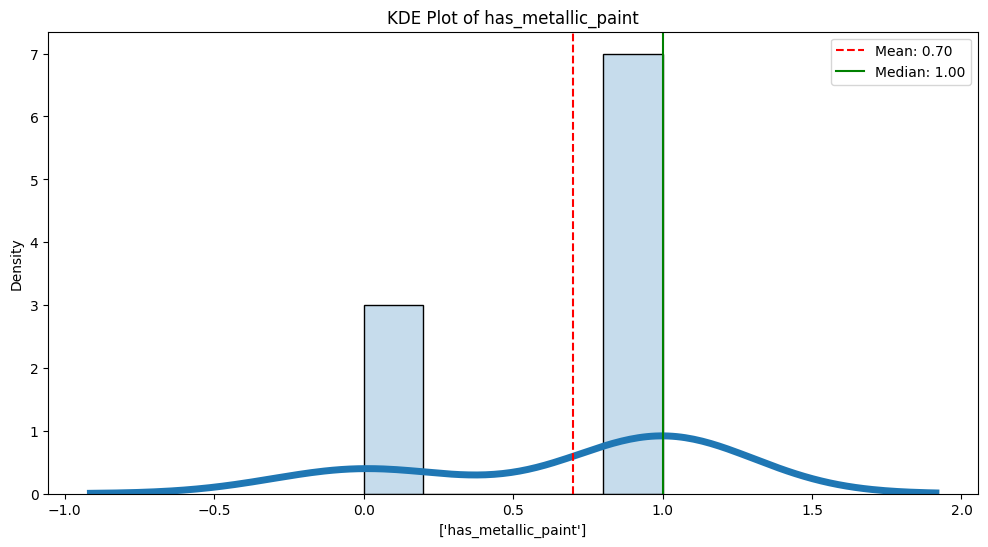

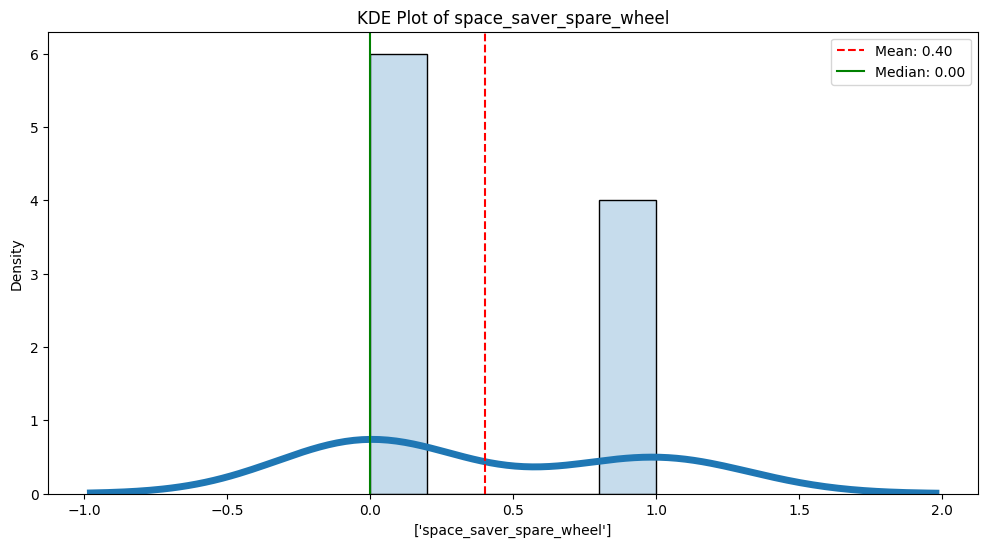

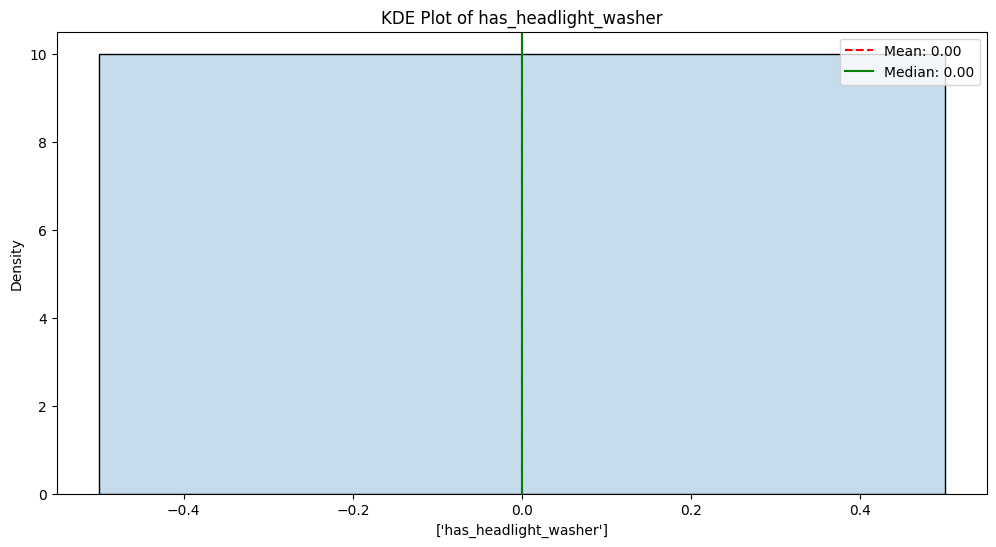

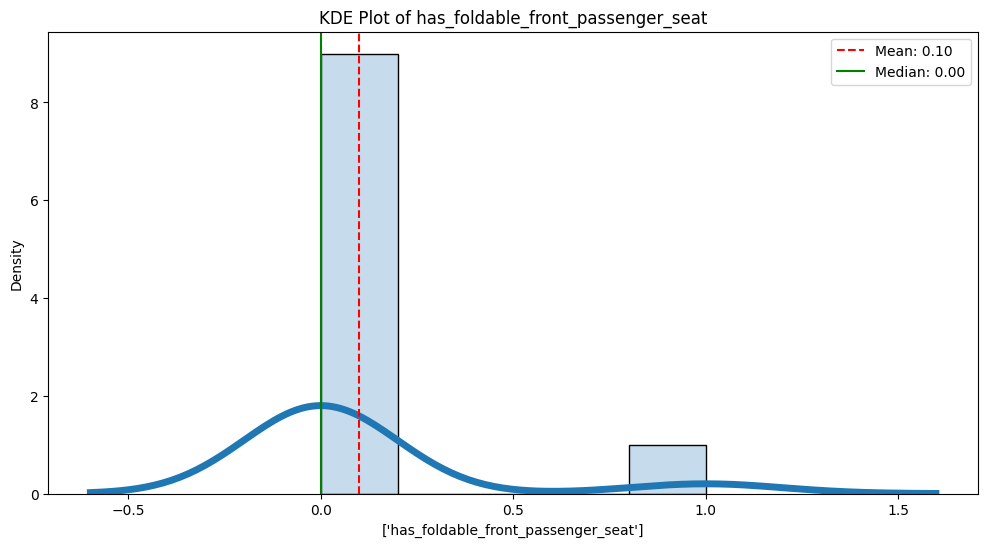

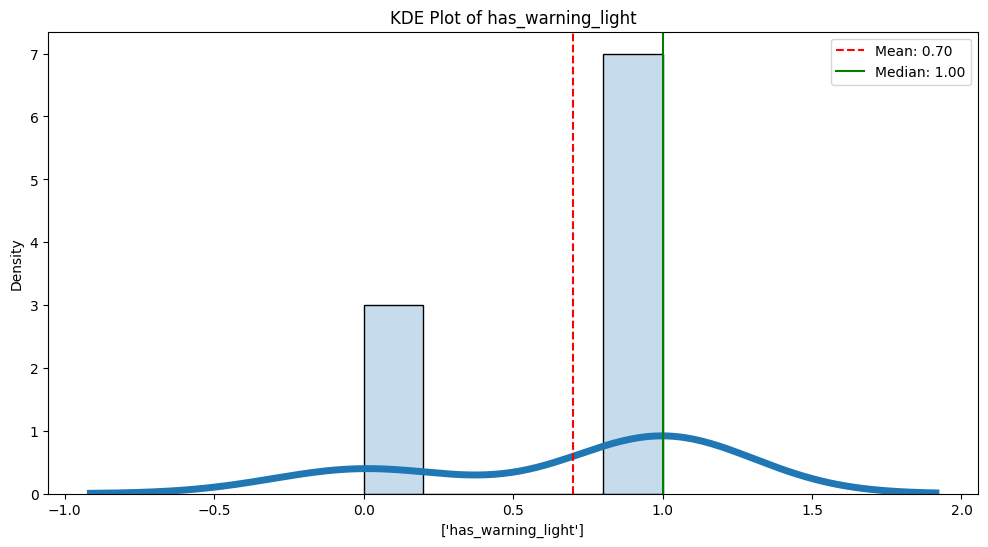

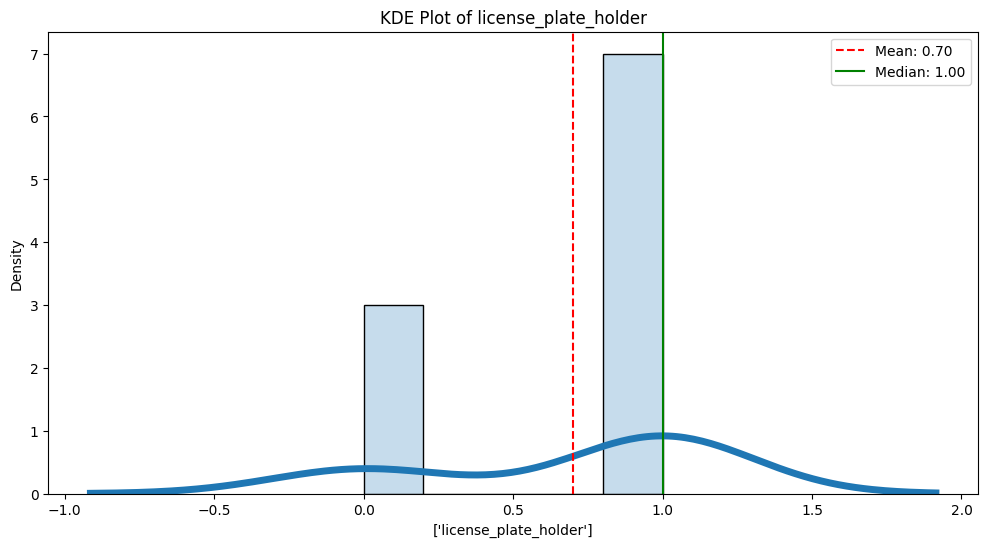

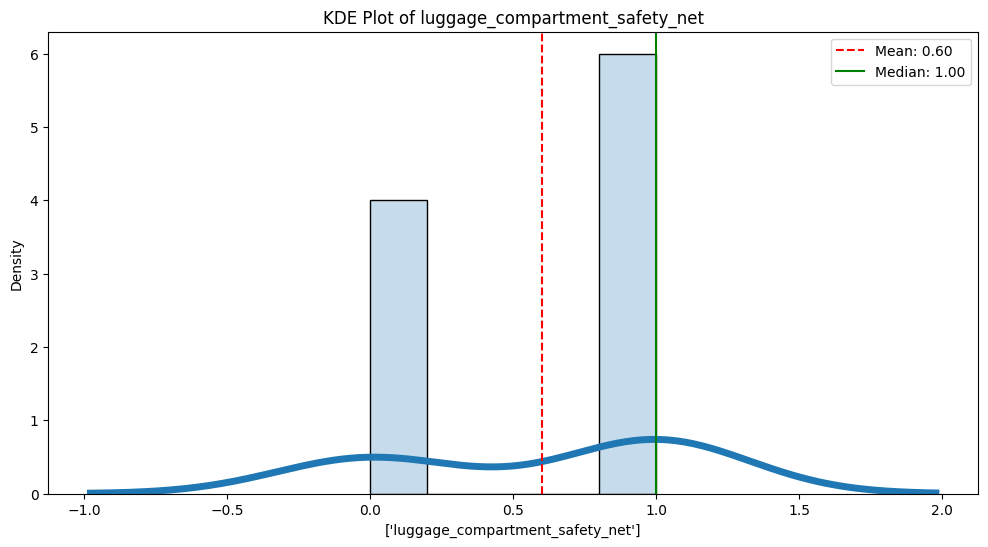

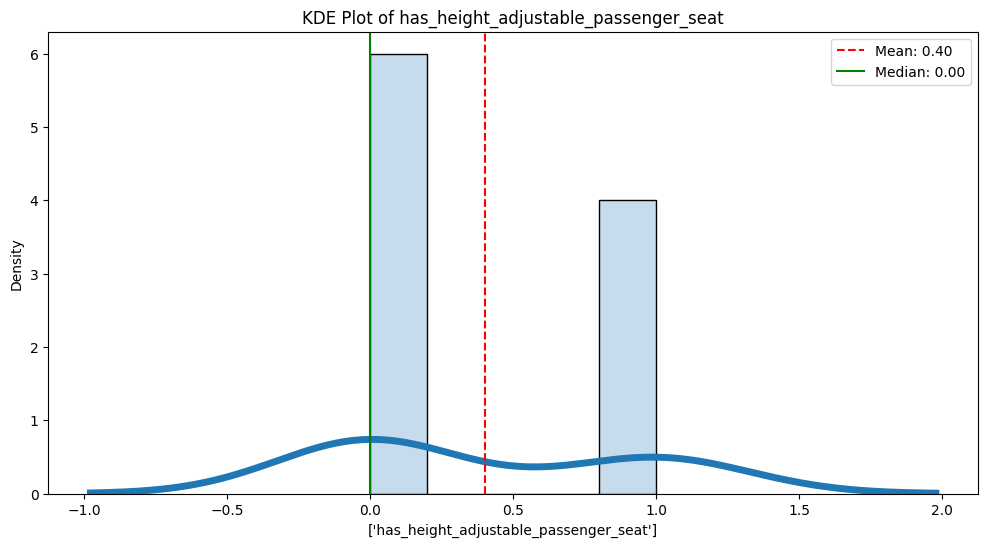

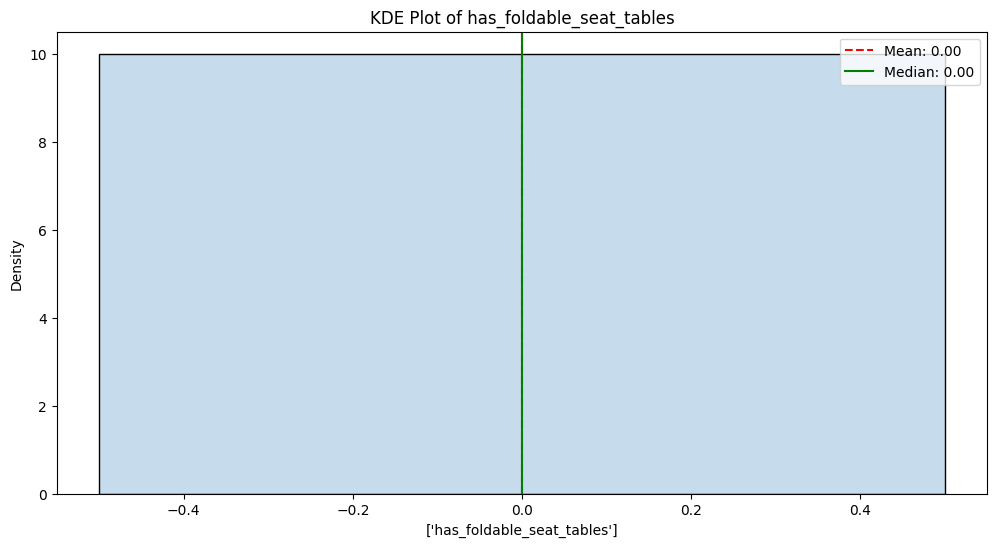

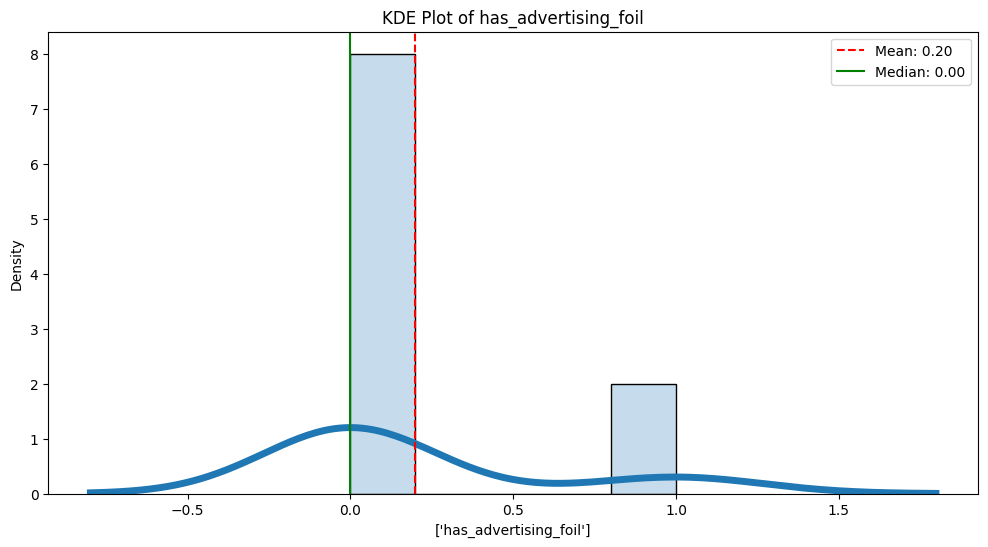

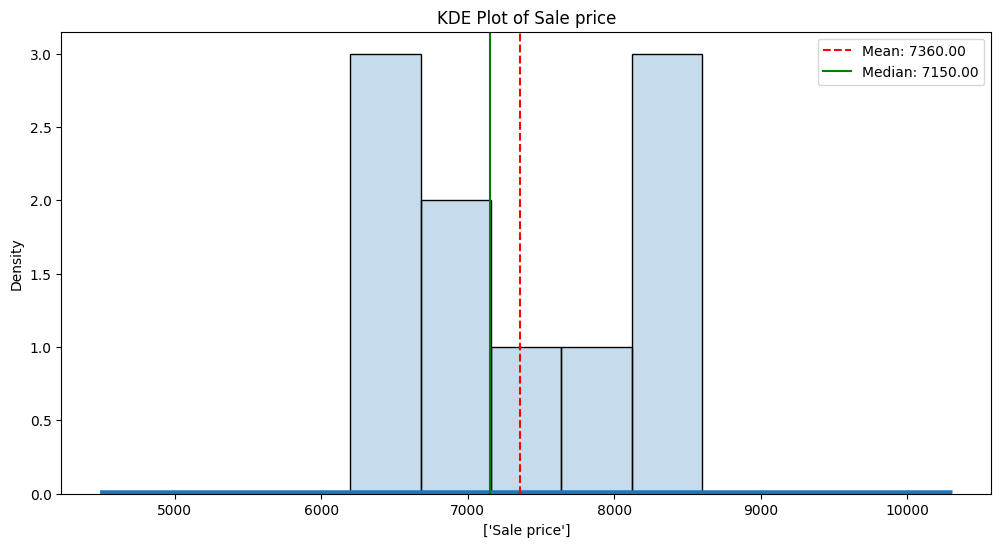

In [5]:
# Generate KDE plots for all numerical columns
for col in numerical_cols:
    kde_plot([col])

    print('\n\n')

#### Scatter Plot

In [6]:
def scatter_plot(x):
    col=x[0]

    plt.figure(figsize=(12,6))

    # Scatter plot with regression line 
    sns.scatterplot(x=data[col], y=data['Price (EUR)'], alpha=0.5, color='red')
    sns.regplot(x=data[col], y=data['Price (EUR)'], scatter=False, color='black', line_kws={"linewidth":3})
    # Add labels and title 
    plt.title(f'Scatter Plot of {col} vs Price (EUR)')
    plt.xlabel(col)
    plt.ylabel('Price (EUR)')

    return plt.show()

In [7]:
for col in numerical_cols:
    scatter_plot([col])

KeyError: 'Price (EUR)'

<Figure size 1200x600 with 0 Axes>

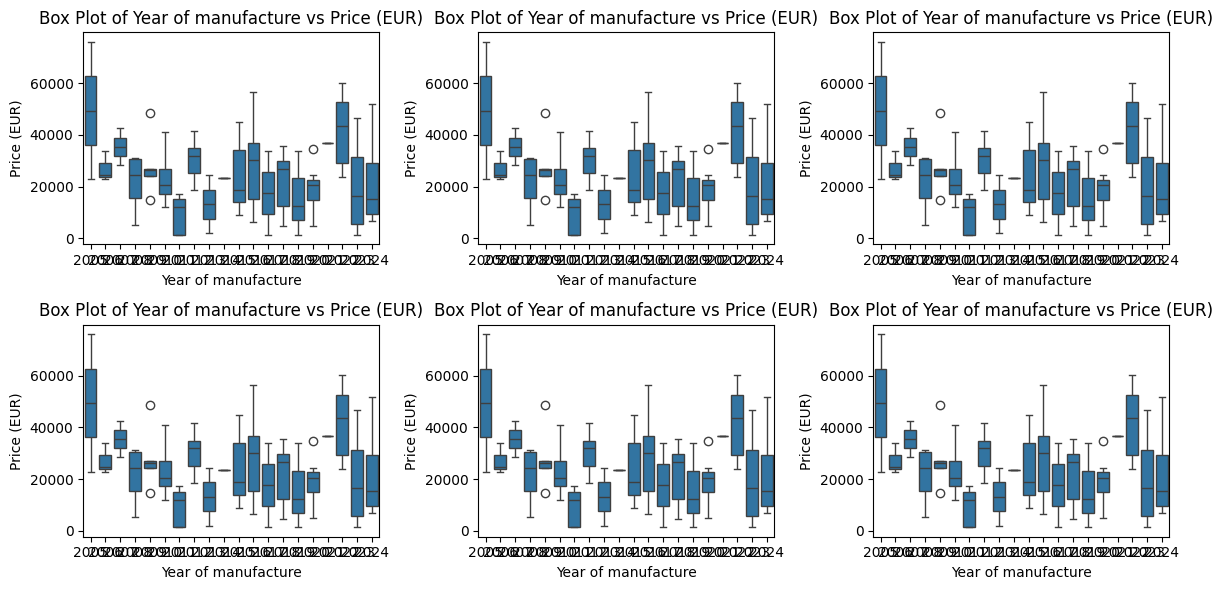

In [ ]:
def box_plot(x):
    col=x[0]
    
    fig, axes = plt.subplots(nrows=2, ncols=3,figsize=(12,6))

    for i, ax in enumerate(axes.flatten()):
        sns.boxplot(x=data[col], y=data['Price (EUR)'], ax=ax)
        ax.set_title(f'Box Plot of {col} vs Price (EUR)')
        ax.set_xlabel(col)
        ax.set_ylabel('Price (EUR)')

    plt.tight_layout()
    return plt.show()
        
box_plot(numerical_cols)


#### Correlation Variables
Analyse relation between variables.

Domain: -1 to 1

. 1 -> perfect positive correlation
. -1 -> perfect negative correlation
. 0 -> no correlation


| r (Korrelationskoeffizient) | Stärke des Zusammenhangs |
| --------------------------- | ------------------------ |
| 0.00 – 0.19                 | sehr schwach             |
| 0.20 – 0.39                 | schwach                  |
| 0.40 – 0.59                 | mittel                   |
| 0.60 – 0.79                 | stark                    |
| 0.80 – 1.0                  | sehr stark               |


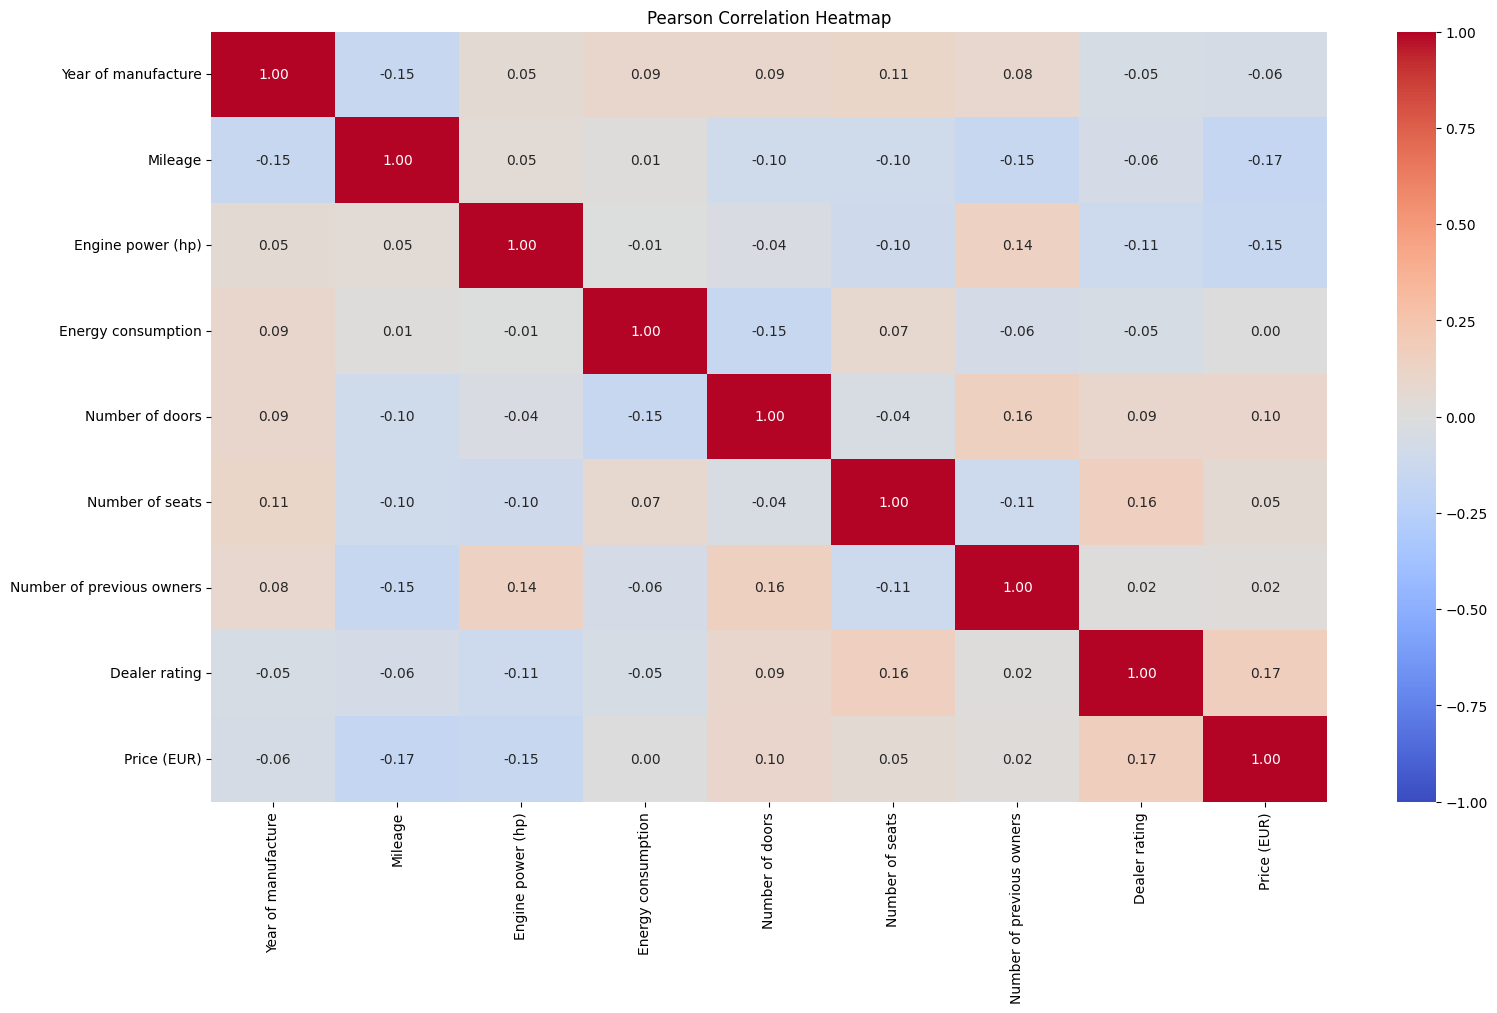

In [ ]:
pearson_corr = data[numerical_cols].corr(method='pearson')
plt.figure(figsize=(18, 10))
sns.heatmap(pearson_corr,
             annot=True,
             vmax=1,
             vmin=-1,
             fmt=".2f", 
             cmap='coolwarm', 
             center=0)
plt.title('Pearson Correlation Heatmap')
plt.show()